## A1 - Data acquisition and cleaning 

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

with open("business-licences.geojson", "r", encoding="utf-8") as file:
    geojson_data = json.load(file)

print("Top-level keys:", geojson_data.keys())
print("Number of features:", len(geojson_data["features"]))

Top-level keys: dict_keys(['type', 'features'])
Number of features: 204160


In [2]:
geojson_data["features"][0].keys()

dict_keys(['type', 'geometry', 'properties'])

In [3]:
#normalize the properties of each feature into a flat table
#normalize creates a flat table from nested JSON data, making it easier 
#to work with in pandas gives us lat and long
properties = [
    feature["properties"]
    for feature in geojson_data["features"]
]

df = pd.json_normalize(properties, sep="_")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (204160, 27)


,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,...,country,postalcode,localarea,numberofemployees,feepaid,extractdate,geom,geo_point_2d,geo_point_2d_lon,geo_point_2d_lat
0,24,4518841,24-138560,10,Nobl Collective Ltd,NaN,Issued,2023-12-28T13:34:28-08:00,2024-12-31,Consulting and Management Services,...,CA,NaN,Kitsilano,1.0,NaN,2026-07-01T02:32:17-07:00,NaN,NaN,NaN,NaN
1,24,4518843,24-138562,10,645064 BC Ltd,Trade Exchange Canada,Issued,2023-11-20T13:40:18-08:00,2024-12-31,Business Support Services,...,CA,NaN,Kitsilano,1.0,NaN,2026-07-01T02:32:17-07:00,NaN,NaN,NaN,NaN
2,24,4518844,24-138563,10,(Louise Turgeon),Turgeon Business Consulting,Issued,2023-11-21T14:30:07-08:00,2024-12-31,Consulting and Management Services,...,CA,NaN,Downtown,1.0,NaN,2026-07-01T02:32:17-07:00,NaN,NaN,NaN,NaN
3,24,4518848,24-138567,10,Baron Global Financial Canada Ltd,NaN,Issued,2023-12-11T10:12:12-08:00,2024-12-31,Consulting and Management Services,...,CA,V6E 2E9,Downtown,5.0,NaN,2026-07-01T02:32:17-07:00,NaN,NaN,-123.118193,49.287734
4,24,4518856,24-138576,10,Jennifer D S Dezell (Jennifer Dezell),Dentons Canada LLP,Issued,2023-12-08T16:34:17-08:00,2024-12-31,Legal Services,...,CA,V6C 3R8,Downtown,217.0,NaN,2026-07-01T02:32:17-07:00,NaN,NaN,-123.113252,49.286653


In [4]:
# inspect the data types and structure
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
df.info()

Dataset shape: (204160, 27)

Column names:
['folderyear', 'licencersn', 'licencenumber', 'licencerevisionnumber', 'businessname', 'businesstradename', 'status', 'issueddate', 'expireddate', 'businesstype', 'businesssubtype', 'unit', 'unittype', 'house', 'street', 'city', 'province', 'country', 'postalcode', 'localarea', 'numberofemployees', 'feepaid', 'extractdate', 'geom', 'geo_point_2d', 'geo_point_2d_lon', 'geo_point_2d_lat']

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 204160 entries, 0 to 204159
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   folderyear             204160 non-null  str    
 1   licencersn             204160 non-null  str    
 2   licencenumber          204160 non-null  str    
 3   licencerevisionnumber  204160 non-null  str    
 4   businessname           190687 non-null  str    
 5   businesstradename      77338 non-null   str    
 6   status                 20

In [5]:
#make the numeric columns numeric so we can do math on them
numeric_columns = ["numberofemployees", "feepaid"]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

#display the numerical columns summary statistics
display(
    df[["numberofemployees", "feepaid"]].describe()
)

,numberofemployees,feepaid
count,204160.000000,128711.000000
mean,10.025495,516.977709
std,72.788764,1110.171048
min,0.000000,2.000000
25%,0.000000,207.000000
50%,1.000000,277.000000
75%,4.000000,405.000000
max,5876.000000,63722.000000


In [6]:
# find missing values in the dataset
missing_columns = [
    "numberofemployees",
    "feepaid",
    "businesssubtype",
    "postalcode",
    "geo_point_2d_lat",
    "geo_point_2d_lon"
]

missing_summary = pd.DataFrame({
    "missing_count": df[missing_columns].isna().sum(),
    "missing_percent": df[missing_columns].isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_summary.round(2))

,missing_count,missing_percent
businesssubtype,182631,89.45
geo_point_2d_lat,101573,49.75
geo_point_2d_lon,101573,49.75
postalcode,95169,46.61
feepaid,75449,36.96
numberofemployees,0,0.00


In [7]:
#check the status column for unique values and their counts
status_counts = df["status"].value_counts(dropna=False)

display(status_counts.to_frame("count"))

,count
status,
Issued,167044
Pending,14941
Gone Out of Business,10434
Inactive,6567
Cancelled,5174


In [8]:
#keep only the records with status "Issued" for further analysis
df_issued = df.loc[df["status"] == "Issued"].copy()

print("Original records:", len(df))
print("Issued records:", len(df_issued))
print(
    "Percentage retained:",
    round(len(df_issued) / len(df) * 100, 2),
    "%"
)

Original records: 204160
Issued records: 167044
Percentage retained: 81.82 %


### A1 Markdown - keeping only issued licences
I chose to keep the licences with a status of "Issued" because it represents all the businesses that are fully operational. The other statuses such as, Pending, cancelled, inactive, and gone-out-of business means that a business is not operating and could further lead to misleading patterns in future analysis. This filter keeps 81.82% of the original dataset (167044 issued records).

In [9]:
# handle all the records without coordinates by dropping them from the dataset
df_issued_clean = df_issued.dropna(subset=["geo_point_2d_lat", "geo_point_2d_lon"])
display(df_issued_clean[["geo_point_2d_lat", "geo_point_2d_lon"]].head())

#rename lat and long columns for clarity
df_issued_clean = df_issued_clean.rename(
    columns={
        "geo_point_2d_lat": "latitude",
        "geo_point_2d_lon": "longitude"
    }
)

print("Issued records:", len(df_issued))
print("Map-ready records:", len(df_issued_clean))
print("Records dropped:", len(df_issued) - len(df_issued_clean))

,geo_point_2d_lat,geo_point_2d_lon
3,49.287734,-123.118193
4,49.286653,-123.113252
5,49.286130,-123.119730
6,49.285359,-123.114570
7,49.235652,-123.042117


Issued records: 167044
Map-ready records: 85890
Records dropped: 81154


### A1 Markdown - removing empty coordinates

I dropped all the issued licenses that had missing coordinates such as lat and long since these cannot be displayed on a map or used for location-based clustering, which is required for A2. Although this removes half of the issued records, keeping it would not be useful for geographic information.

In [10]:
#recheck the missing values in the cleaned dataset
filtered_missing_columns = [
    "numberofemployees",
    "feepaid",
    "businesssubtype",
    "postalcode",
    "latitude",
    "longitude"
]

filtered_missingness = pd.DataFrame({
    "missing_count": df_issued_clean[filtered_missing_columns].isna().sum(),
    "missing_percent":
        df_issued_clean[filtered_missing_columns].isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(filtered_missingness.round(2))

,missing_count,missing_percent
businesssubtype,69715,81.17
feepaid,26483,30.83
postalcode,654,0.76
numberofemployees,0,0.00
latitude,0,0.00
longitude,0,0.00


In [11]:
df_issued_clean["feepaid_missing"] = (
    df_issued_clean["feepaid"].isna().astype(int)
)

In [12]:
business_type_median = (
    df_issued_clean
    .groupby("businesstype")["feepaid"]
    .transform("median")
)

overall_fee_median = df_issued_clean["feepaid"].median()

df_issued_clean["feepaid_clean"] = (
    df_issued_clean["feepaid"]
    .fillna(business_type_median)
    .fillna(overall_fee_median)
)

print(
    "Remaining missing fee values:",
    df_issued_clean["feepaid_clean"].isna().sum()
)

Remaining missing fee values: 0


### A1 Markdown - handling missing fee

records with missing feepaid were not dropped because it would make the dataset too small, so missing values were replaced with the median value of the fee prices of the same business type since different industries have different values. 

In [13]:
# Count the number of businesses for each type
business_counts = df_issued_clean["businesstype"].value_counts()

print("Number of business types:", business_counts.size)
display(business_counts.head(20).to_frame("count"))

Number of business types: 90


,count
businesstype,
Health Care Professionals and Services,11806
Long-term Rental,10266
Retail Dealer,6140
Legal Services,5213
Restaurant,4915
Beauty Services,3940
Limited Service Food Establishment,3815
Business Support Services,2962
Financial Services,2401


In [14]:
business_coverage = pd.DataFrame({
    "count": business_counts
})

business_coverage["share"] = (
    business_coverage["count"] / business_coverage["count"].sum()
)

business_coverage["cumulative_share"] = (
    business_coverage["share"].cumsum()
)

display(business_coverage.head(30))

,count,share,cumulative_share
businesstype,,,
Health Care Professionals and Services,11806,0.137455,0.137455
Long-term Rental,10266,0.119525,0.256980
Retail Dealer,6140,0.071487,0.328467
Legal Services,5213,0.060694,0.389161
Restaurant,4915,0.057224,0.446385
Beauty Services,3940,0.045873,0.492258
Limited Service Food Establishment,3815,0.044417,0.536675
Business Support Services,2962,0.034486,0.571161
Financial Services,2401,0.027954,0.599115


In [15]:
# BEGIN CHATGPT
# PROMPT: how do i keep only the top business types that cover 85% of the 
# businesses and group the rest into an "Other" category?
def consolidate_categories(series, coverage=0.85):
    counts = series.value_counts()
    cumulative = counts.cumsum() / counts.sum()

    number_to_keep = (
        np.searchsorted(cumulative.to_numpy(), coverage) + 1
    )

    categories_to_keep = counts.index[:number_to_keep]

    consolidated = series.where(
        series.isin(categories_to_keep),
        "Other"
    )

    return consolidated, categories_to_keep

In [16]:
df_issued_clean["business_group"], top_business_types = (
    consolidate_categories(
        df_issued_clean["businesstype"],
        coverage=0.85
    )
)

print("Business types retained:", len(top_business_types))
print("\nRetained categories:")
print(top_business_types.tolist())

display(
    df_issued_clean["business_group"]
    .value_counts()
    .to_frame("count")
)
# END CHATGPT

Business types retained: 27

Retained categories:
['Health Care Professionals and Services', 'Long-term Rental', 'Retail Dealer', 'Legal Services', 'Restaurant', 'Beauty Services', 'Limited Service Food Establishment', 'Business Support Services', 'Financial Services', 'Consulting and Management Services', 'Real Estate Services', 'Retail Dealer - Food', 'General Contractor', 'Association or Society', 'Information Communication Technology', 'Wholesale Dealer - Non-Food', 'Parking Area / Garage', 'Health Care Facility', 'Architectural and Engineering Services', 'Non-Food Manufacturer Assembler and Processor', 'Vehicle Repair Detailing and Washing Services', 'Food Manufacturer Assembler and Processor', 'Photography Production and Rehearsal Studio', 'Insurance Services', 'Mining Services', 'Fitness Centre', 'Liquor Establishment']


,count
business_group,
Other,12528
Health Care Professionals and Services,11806
Long-term Rental,10266
Retail Dealer,6140
Legal Services,5213
Restaurant,4915
Beauty Services,3940
Limited Service Food Establishment,3815
Business Support Services,2962


### A1 Markdown - grouping business types

The original businesstype column contains 94 categories with many categories having very few records. The records with lesser categories would make reading data visualizations difficult. Based on the frequency of categories, I made sure to keep the top categories that are able to represent 85% of the map records and the remaining categories are grouped into "Other". This cleaning reduces the 94 categories into 28 categories.

In [17]:
# BEGIN CHATGPT
# PROMPT: how do i keep a sample size of 10000 business from the dataset while maintaining the same distribution of business types?

SAMPLE_SIZE = 10_000

df_sample = df_issued_clean.sample(
    n=min(SAMPLE_SIZE, len(df_issued_clean)),
    random_state=42
).reset_index(drop=True)

print("Full cleaned issued dataset:", df_issued_clean.shape)
print("Sampled dataset:", df_sample.shape)

# END CHATGPT

Full cleaned issued dataset: (85890, 30)
Sampled dataset: (10000, 30)


### A1 Markdown - creating a sample size for Streamlit

I decided to create a sample size from the cleaned data so it would be easy to use and manage for future use in streamlit. The cleaned dataset contains 85,890 records and the sample was reduced to 10,000 records using random_state=42. This size was chosen since it is small enough for plotting, clustering, and Streamlit responsiveness. 

In [18]:
# show the dataframe columns and their data types
df_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   folderyear             10000 non-null  str    
 1   licencersn             10000 non-null  str    
 2   licencenumber          10000 non-null  str    
 3   licencerevisionnumber  10000 non-null  str    
 4   businessname           10000 non-null  str    
 5   businesstradename      4968 non-null   str    
 6   status                 10000 non-null  str    
 7   issueddate             9984 non-null   str    
 8   expireddate            9984 non-null   str    
 9   businesstype           10000 non-null  str    
 10  businesssubtype        1915 non-null   str    
 11  unit                   4307 non-null   str    
 12  unittype               4289 non-null   str    
 13  house                  10000 non-null  str    
 14  street                 10000 non-null  str    
 15  city          

In [19]:
final_columns = [
    'folderyear',
    'licencersn',
    'licencenumber',
    'licencerevisionnumber',
    'businessname',
    'businesstradename',
    'status',
    'issueddate',
    'expireddate',
    'businesstype',
    'businesssubtype',
    'unit',
    'unittype',
    'house',
    'street',
    'city',
    'province',
    'country',
    'postalcode',
    'localarea',
    'numberofemployees',
    'feepaid',
    'extractdate',
    'geom',
    'geo_point_2d',
    'longitude',
    'latitude',
    'feepaid_missing',
    'feepaid_clean',
    'business_group'
]

df_final = df_sample[final_columns].copy()

display(df_final.head())
print(df_final.shape)

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,...,numberofemployees,feepaid,extractdate,geom,geo_point_2d,longitude,latitude,feepaid_missing,feepaid_clean,business_group
0,25,4642276,25-134553,00,The Lemon Square Inc,The Lemon Square,Issued,2024-12-03T17:18:40-08:00,2025-12-31,Food Manufacturer Assembler and Processor,...,4.0,510.0,2026-07-01T02:32:21-07:00,NaN,NaN,-123.119287,49.276087,0,510.0,Food Manufacturer Assembler and Processor
1,25,4702264,25-179344,01,Donald Bruce Luxton (Donald Luxton),Donald Luxton & Associates,Issued,2025-03-14T08:40:11-07:00,2025-12-31,Consulting and Management Services,...,7.0,297.0,2026-07-01T02:32:23-07:00,NaN,NaN,-123.106006,49.284083,0,297.0,Consulting and Management Services
2,24,4513548,24-132572,10,Pelco Management Company Ltd,NaN,Issued,2023-12-27T16:11:28-08:00,2024-12-31,Real Estate Services,...,17.0,NaN,2026-07-01T02:32:16-07:00,NaN,NaN,-123.117580,49.286052,1,277.0,Real Estate Services
3,25,4617071,25-109350,00,Hai Di Lao Canada Restaurants Group Ltd,HaiDiLao Hot Pot,Issued,2024-12-28T15:25:55-08:00,2025-12-31,Restaurant,...,20.0,2894.0,2026-07-01T02:32:19-07:00,NaN,NaN,-123.176219,49.263948,0,2894.0,Restaurant
4,24,4525177,24-145025,10,Manh Cuong Nguyen & Thu Thao Nguyen,Sunrises - Asian Antiques & More,Issued,2023-12-05T22:39:25-08:00,2024-12-31,Retail Dealer,...,2.0,NaN,2026-07-01T02:32:17-07:00,NaN,NaN,-123.057627,49.281426,1,277.0,Retail Dealer


(10000, 30)


In [20]:
df_final.to_csv(
    "business_licences_clean_sample.csv",
    index=False
)

### A1 Final Markdown

The original geojson contained 204160 business licence records and 25 property fields. I normalized the feature properties, inspected the structure, data types, and any missing values. I then kept all 167044 of the business records that had a business status of "Issued" since the other values represented that the business was not currently operational. I then dropped all the values without complete geographic coordinates since those values could not be mapped or be used for location clustering, which left me with 85890 map ready records. About 30% of the map ready records had a missing "feepaid", so these missing values were replaced with the median value of the type of business industry the business was in. All 94 business types were combined a new category called "Other" and the top 27 categories were kept outside of the "Other" category. Finally, I reduced the sample size of the current records to 10000 records to make plotting, clustering, and Streamlit interactions more responsive. 

## A2 Location-only clustering: K-means vs. DBSCAN

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN

In [24]:
# Use the cleaned sample from A1
cluster_df = df_final.dropna(
    subset=["latitude", "longitude"]
).copy()

print("Businesses used for clustering:", len(cluster_df))
display(cluster_df[["latitude", "longitude"]].describe())

Businesses used for clustering: 10000


,latitude,longitude
count,10000.000000,10000.000000
mean,49.265443,-123.111416
std,0.021656,0.032295
min,49.201581,-123.219197
25%,49.259460,-123.127504
50%,49.269098,-123.116662
75%,49.282464,-123.097484
max,49.298055,-123.024016


In [25]:
EARTH_RADIUS = 6_371_000  # metres

# Use the centre of the Vancouver data as the reference point
mean_lat = cluster_df["latitude"].mean()
mean_lon = cluster_df["longitude"].mean()

lat_radians = np.radians(
    cluster_df["latitude"] - mean_lat
)

lon_radians = np.radians(
    cluster_df["longitude"] - mean_lon
)

# Approximate local x/y distance in metres
cluster_df["x_metres"] = (
    EARTH_RADIUS
    * lon_radians
    * np.cos(np.radians(mean_lat))
)

cluster_df["y_metres"] = (
    EARTH_RADIUS
    * lat_radians
)

# Only these two location features are used
X_location = cluster_df[
    ["x_metres", "y_metres"]
].to_numpy()

print("Clustering feature shape:", X_location.shape)

Clustering feature shape: (10000, 2)


In [26]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_location)
    inertias.append(model.inertia_)

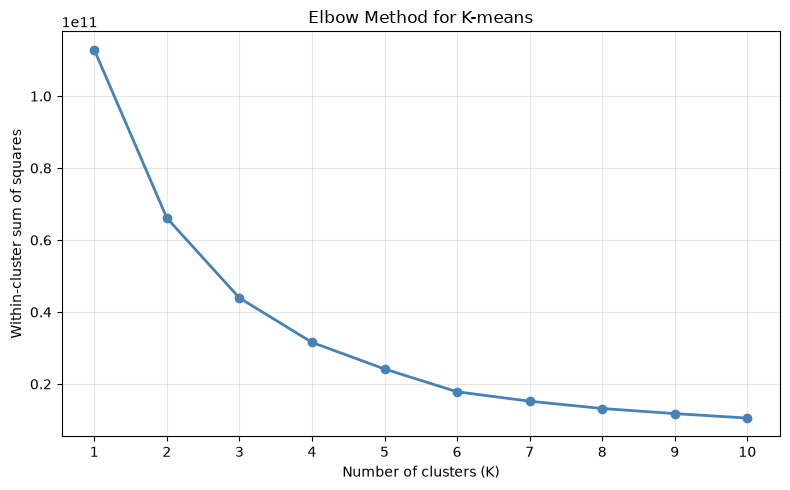

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o",
    linewidth=2,
    color="steelblue"
)

plt.xticks(list(k_values))
plt.title("Elbow Method for K-means")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Within-cluster sum of squares")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
chosen_k = 6

kmeans = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)

cluster_df["kmeans_cluster"] = kmeans.fit_predict(
    X_location
)

print(
    cluster_df["kmeans_cluster"]
    .value_counts()
    .sort_index()
)

kmeans_cluster
0    1620
1    1139
2    3899
3     682
4    1870
5     790
Name: count, dtype: int64
